In [4]:

import lightkurve as lk
import matplotlib.pyplot as plt

D:\NASA TESS analysis\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [6]:
search = lk.search_targetpixelfile("NGC7335",mission="TESS")
tpf = search[0].download()
mask = tpf.create_threshold_mask(threshold=5)


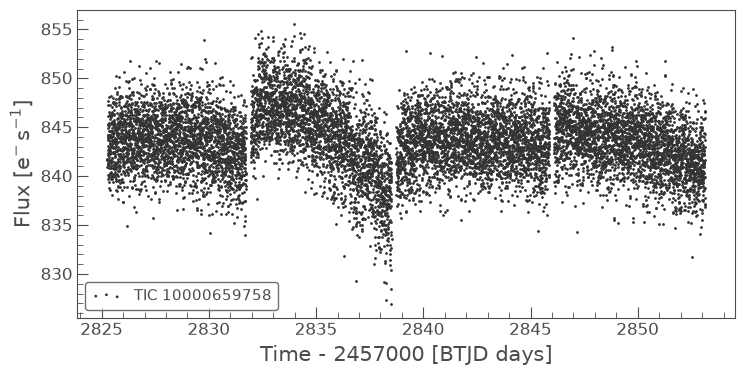

In [7]:
lc = tpf.to_lightcurve(aperture_mask=mask)
lc.scatter()
plt.show()

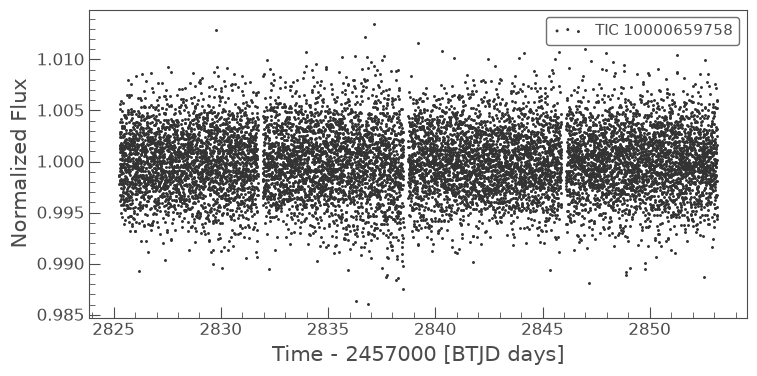

In [8]:
clean = lc.remove_nans()
filtered = clean.remove_outliers()

flatten = filtered.flatten()
flatten.scatter(s=5)
plt.show()

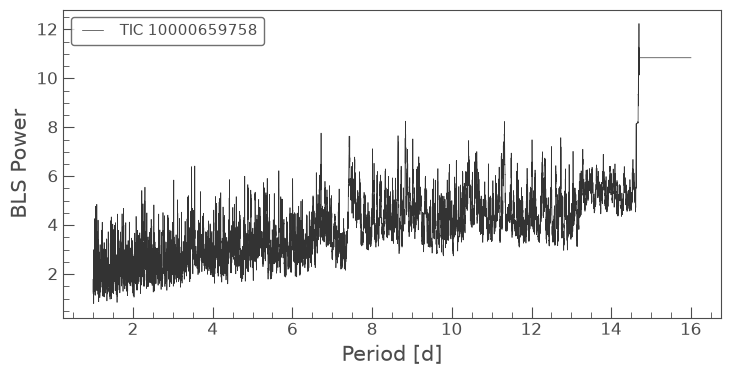

In [15]:
import numpy as np

periodogram = flatten.to_periodogram(method = 'bls', period = np.arange(1,16,0.001))

periodogram.plot()
plt.show()


In [16]:
best_period = periodogram.period_at_max_power

print("Best period:", best_period)


Best period: 14.693999999998493 d


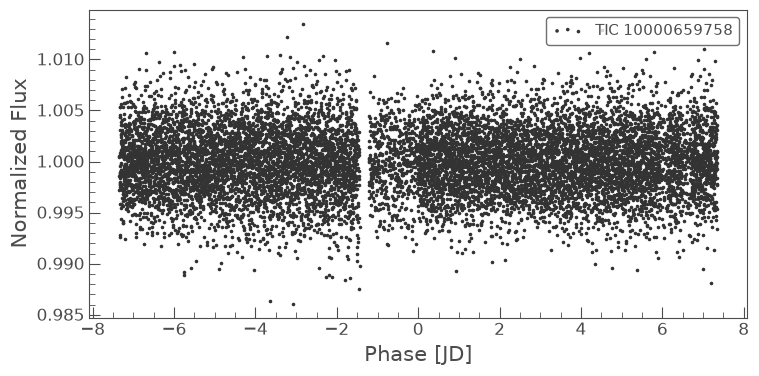

In [22]:
folded_lc = flatten.fold(period=14.693999999998493)
folded_lc.scatter(s=10)
plt.show()